<a href="https://colab.research.google.com/github/takuonakashima/ai-security-workshop/blob/main/mnist_fgsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.43MB/s]


GitHubから学習済みモデルをダウンロードしています...

=== 🛡️ 攻撃前のAIの推論結果 ===
AIの予測: 『 8 』 (確信度: 39.75%)
本当の正解: 『 5 』

=== ⚔️ FGSM攻撃を開始します ===
【攻撃後】AIの予測: 『 8 』 (確信度: 51.89%)
本当の正解: 『 5 』


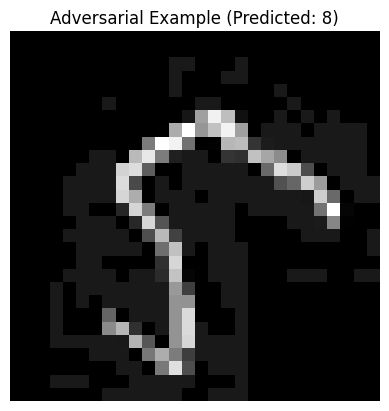

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os
import urllib.request
import matplotlib.pyplot as plt  # ← 画像表示のために追加しました

# ==========================================
# 1. データの準備とモデルの定義
# ==========================================
# データの変換ルールとダウンロード、ベルトコンベア(train_loader)の作成
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# 画像分類AIの構造（設計図）を定義する
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1) # 画像の特徴を抽出する層
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)     # 特徴から数字を判定する層
        self.fc2 = nn.Linear(128, 10)       # 0〜9の10クラスに分類

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x # 0〜9のそれぞれの数字っぽさの「生のスコア（Logit）」を出力

# モデルの実体を作成し、GPU環境にセットする
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# ==========================================
# 2. 学習済みの脳（パラメータ）の読み込み
# ==========================================
print("GitHubから学習済みモデルをダウンロードしています...")
url = 'https://raw.githubusercontent.com/takuonakashima/ai-security-workshop/main/mnist_cnn.pth'
urllib.request.urlretrieve(url, 'mnist_cnn.pth')

# ダウンロードした脳みそをAIに注入する
model.load_state_dict(torch.load('mnist_cnn.pth', map_location=device))
model.eval() # AIモデルを「推論（テスト）モード」に切り替える

# ==========================================
# 3. 攻撃前の推論（正常な画像でのテスト）
# ==========================================
# データローダーから画像と正解ラベルを1つ取り出す
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 用意した画像をGPUに送り、AIに入力する
images = images.to(device)
labels = labels.to(device)

# AIに予測させる
output = model(images)
probabilities = F.softmax(output, dim=1)
max_prob, predicted_class = torch.max(probabilities, 1)

print("\n=== 🛡️ 攻撃前のAIの推論結果 ===")
print(f"AIの予測: 『 {predicted_class.item()} 』 (確信度: {max_prob.item() * 100:.2f}%)")
print(f"本当の正解: 『 {labels[0].item()} 』")

# ==========================================
# 4. FGSM攻撃の実行
# ==========================================
# FGSM攻撃を行う関数
def fgsm_attack(image, epsilon, data_grad):
    # 勾配（Lossの傾き）の「プラスかマイナスか」の符号(sign)を取得
    sign_data_grad = data_grad.sign()

    # 元の画像に、イプシロン(ノイズ強度) × 符号 を足し合わせる
    perturbed_image = image + epsilon * sign_data_grad

    # ピクセル値が 0.0 〜 1.0 の範囲に収まるようにクリッピング
    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image

print("\n=== ⚔️ FGSM攻撃を開始します ===")
epsilon = 0.1 # 攻撃の強さ

# 画像に対する勾配を計算できるように設定
images.requires_grad = True

# 1. まず普通にAIに推論させる
output = model(images)
# （※本来 logits 出力に対しては F.cross_entropy が適していますが、資料の記載通り進めます）
loss = F.nll_loss(output, labels)

# 2. AIのモデル全体を「逆伝播」させ、画像に対する「Lossの傾き（勾配）」を計算する
model.zero_grad()
loss.backward()

# 計算された画像に対する勾配データを取得
data_grad = images.grad.data

# 3. FGSM攻撃関数を呼び出し、敵対的サンプルを作成！
perturbed_data = fgsm_attack(images, epsilon, data_grad)

# 4. 作成した毒入り画像（敵対的サンプル）を、もう一度AIに入力する
output_adv = model(perturbed_data)
max_prob_adv, predicted_adv = torch.max(F.softmax(output_adv, dim=1), 1)

# 結果の表示
print(f"【攻撃後】AIの予測: 『 {predicted_adv.item()} 』 (確信度: {max_prob_adv.item()*100:.2f}%)")
print(f"本当の正解: 『 {labels[0].item()} 』")

# 攻撃画像の表示
plt.imshow(perturbed_data[0].detach().cpu().numpy().squeeze(), cmap='gray')
plt.title(f"Adversarial Example (Predicted: {predicted_adv.item()})")
plt.axis('off')
plt.show()